# QuRad Example Application

Analysis of radiomics features extracted from GBM whole slide images.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import anndata as ad
import scanpy as sc
import gc

radiomics_dir = Path('/Users/tamara/Desktop/PyRadiomics/Qupath/radiomics')

# Timepoint mapping
TIMEPOINT_MAP = {
    'ILR_201': 'T0', 'ILR_266': 'T0', 'ILR_192': 'T0',
    'ILR_239': 'T1', 'ILR_247': 'T1', 'ILR_265': 'T1',
    'ILR_244': 'Tn', 'ILR_236': 'Tn', 'ILR_232': 'Tn'
}

# File mapping (sample_id -> filename)
FILES = {
    'ILR_192': 'ILR_192_11_17_36_45_ndpi_radiomics_20251222_182542.csv',
    'ILR_201': 'ILR_201_21_16_30_14_ndpi_radiomics_20251229_213027.csv',
    'ILR_232': 'ILR_232_1_15_47_52_ndpi_radiomics_20251229_215321.csv',
    'ILR_236': 'ILR_236_21_14_34_16_ndpi_radiomics_20251229_222340.csv',
    'ILR_239': 'ILR_239_11_14_02_38_ndpi_radiomics_20251229_225058.csv',
    'ILR_244': 'ILR_244_1_15_24_07_ndpi_radiomics_20251229_231613.csv',
    'ILR_247': 'ILR_247_11_14_47_26_ndpi_radiomics_20251223_164005.csv',
    'ILR_265': 'ILR_265_11_15_09_19_ndpi_radiomics_20251226_154432.csv',
    'ILR_266': 'ILR_266_31_16_17_42_ndpi_radiomics_20251229_193651.csv',
}

## Load Radiomics Data

Each file loaded separately - comment out any you want to exclude.

In [2]:
SUBSAMPLE = 0.1  # Use 10% of cells for faster exploration

adatas = []
for sample_id, filename in FILES.items():
    print(f"Loading {sample_id}...", end=" ")
    df = pd.read_csv(radiomics_dir / filename)
    
    # Add Cell_ID (1-indexed row number, matches geojson)
    df['Cell_ID'] = df.index + 1
    
    if SUBSAMPLE < 1.0:
        df = df.sample(10000, random_state=41)
    
    obs_cols = ['Classification', 'ObjectID', 'ObjectType', 'Cell_ID']
    feature_cols = [c for c in df.columns if c not in obs_cols]
    
    adata_i = ad.AnnData(
        X=df[feature_cols].values.astype(np.float32),
        obs=df[obs_cols].copy()
    )
    adata_i.obs['sample'] = sample_id
    adata_i.obs['timepoint'] = TIMEPOINT_MAP[sample_id]
    adata_i.var_names = feature_cols
    
    print(f"{len(adata_i):,} cells")
    adatas.append(adata_i)
    del df
    gc.collect()

adata = ad.concat(adatas, join='outer')
del adatas
gc.collect()

print(f"\n✓ Combined: {adata.n_obs:,} cells × {adata.n_vars} features")
print(f"  Samples: {adata.obs['sample'].nunique()}")

Loading ILR_192... 

/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


10,000 cells
Loading ILR_201... 

/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


10,000 cells
Loading ILR_232... 

...

10,000 cells
Loading ILR_265... 

/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


10,000 cells
Loading ILR_266... 

/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


10,000 cells

✓ Combined: 90,000 cells × 120 features
  Samples: 9


In [3]:
adata.var['feature_class'] = [name.split('_')[0] for name in adata.var_names]
print(adata.var['feature_class'].value_counts())

feature_class
glcm          23
firstorder    19
glrlm         16
glszm         16
shape         16
gldm          15
shape2D       10
ngtdm          5
Name: count, dtype: int64


## Add Timepoint Information

Mapping samples to tumor progression timepoints:
- **T0 (beginning)**: 201, 266, 192
- **T1 (intermediate)**: 239, 247, 265  
- **Tn (endpoint)**: 244, 236, 232

In [4]:
print(adata.obs.groupby(['timepoint', 'sample']).size())

timepoint  sample 
T0         ILR_192    10000
           ILR_201    10000
           ILR_266    10000
T1         ILR_239    10000
           ILR_247    10000
           ILR_265    10000
Tn         ILR_232    10000
           ILR_236    10000
           ILR_244    10000
dtype: int64


In [5]:
# AnnData summary
print(adata)
print(f"\nFeature classes: {adata.var['feature_class'].value_counts().to_dict()}")

AnnData object with n_obs × n_vars = 90000 × 120
    obs: 'Classification', 'ObjectID', 'ObjectType', 'Cell_ID', 'sample', 'timepoint'
    var: 'feature_class'

Feature classes: {'glcm': 23, 'firstorder': 19, 'glrlm': 16, 'glszm': 16, 'shape': 16, 'gldm': 15, 'shape2D': 10, 'ngtdm': 5}


## Preprocessing & Dimensionality Reduction

In [6]:
adata.X = np.nan_to_num(adata.X, nan=0, posinf=0, neginf=0)

# Cluster all cells together
from sklearn.cluster import MiniBatchKMeans

K = 8  # Number of clusters

kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=5000, n_init=3)
adata.obs['cluster'] = kmeans.fit_predict(adata.X).astype(str)

print(f"✓ Clustered into {K} groups")
print(adata.obs['cluster'].value_counts().sort_index())


✓ Clustered into 8 groups
cluster
0     3708
1    14909
2    21289
3    10676
4    11957
5    18934
6     6929
7     1598
Name: count, dtype: int64


In [7]:
# Z-score normalize within each sample
for sample in adata.obs['sample'].unique():
    mask = adata.obs['sample'] == sample
    X_sample = adata.X[mask]
    mean = X_sample.mean(axis=0)
    std = X_sample.std(axis=0) + 1e-8
    adata.X[mask] = (X_sample - mean) / std

print(f"✓ Normalized {adata.n_obs:,} cells within each of {adata.obs['sample'].nunique()} samples")

✓ Normalized 90,000 cells within each of 9 samples


In [8]:
from sklearn.decomposition import PCA
import numpy as np

N_PCS = 30  # keep more than 2; only 2 used for plotting

X = adata.X

# ensure float32 to reduce memory pressure
if X.dtype != np.float32:
    X = X.astype(np.float32)

pca = PCA(
    n_components=N_PCS,
    svd_solver='randomized',  # faster, identical for large n
    random_state=0
)

X_pca = pca.fit_transform(X)
adata.obsm['X_pca'] = X_pca



In [9]:
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 8

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=50_000,
    random_state=0
)

adata.obs['cluster'] = kmeans.fit_predict(adata.obsm['X_pca'])


## Pillar 1: Reproducibility Across Mice

Do the same morphological clusters appear in all mice?

In [10]:
import pandas as pd

pca_df = pd.DataFrame(
    adata.obsm['X_pca'][:, :2],  # PC1 + PC2 only
    columns=['PC1', 'PC2']
)

pca_df['sample']  = adata.obs['sample'].values
pca_df['cluster'] = adata.obs['cluster'].values

centroids = (
    pca_df
    .groupby(['sample', 'cluster'], observed=True)
    .mean()
    .reset_index()
)

In [11]:
import pandas as pd

cells_df = pd.DataFrame(
    adata.obsm['X_pca'][:, :2],
    columns=['PC1', 'PC2']
)

cells_df['cluster'] = adata.obs['cluster'].values
cells_df['sample']  = adata.obs['sample'].values


In [12]:
centroids = (
    cells_df
    .groupby(['sample', 'cluster'], observed=True)
    .mean()
    .reset_index()
)

In [49]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# centroids: DataFrame with columns ['sample', 'cluster', 'PC1', 'PC2']

clusters = centroids['cluster'].unique()
samples = centroids['sample'].unique()

results = []

for k in clusters:
    # get all centroids for this cluster
    df_k = centroids[centroids['cluster'] == k][['PC1', 'PC2']].values
    n_mice = df_k.shape[0]

    if n_mice < 2:
        continue  # skip clusters present in <2 mice

    # pairwise cosine similarity
    S = cosine_similarity(df_k)
    triu_idx = np.triu_indices(n_mice, k=1)  # upper triangle (exclude self)
    sims = S[triu_idx]

    results.append({
        'cluster': k,
        'mean_cosine': sims.mean(),
        'std_cosine': sims.std(),
        'n_pairs': len(sims)
    })

cluster_sims_df = pd.DataFrame(results)

# overall mean similarity
overall_mean = cluster_sims_df['mean_cosine'].mean()
overall_std = cluster_sims_df['mean_cosine'].std()

print(cluster_sims_df)
print(f'Overall mean cosine similarity across clusters: {overall_mean:.3f} ± {overall_std:.3f}')


   cluster  mean_cosine  std_cosine  n_pairs
0        0     0.986160    0.014564       36
1        1     0.966835    0.033239       36
2        2     0.997028    0.004608       36
3        3     0.997499    0.003814       36
4        4     0.995296    0.005285       36
5        5     0.998153    0.002106       36
6        6     0.983561    0.017552       36
7        7     0.991416    0.009792       36
Overall mean cosine similarity across clusters: 0.989 ± 0.011


In [14]:
cells_df_rand = cells_df.copy()

# shuffle cluster labels globally
cells_df_rand['cluster'] = np.random.permutation(cells_df_rand['cluster'].values)


In [15]:
centroids_rand = (
    cells_df_rand
    .groupby(['sample', 'cluster'], observed=True)
    .mean()
    .reset_index()
)

In [36]:
pc1_min, pc1_max = np.percentile(cells_df['PC1'], [0.01, 99.99])
pc2_min, pc2_max = np.percentile(cells_df['PC2'], [0.01, 99.99])

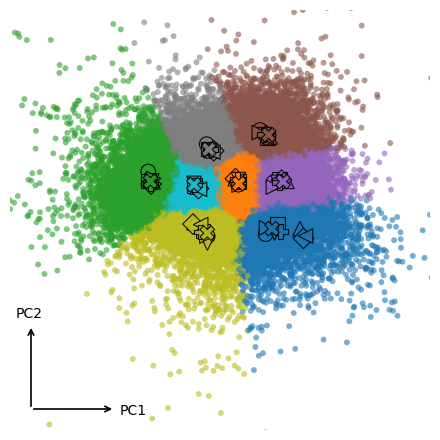

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 4.5))


def style_pca_axis(ax, show_arrows=False):
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_arrows:
        # PC1 arrow (horizontal)
        ax.annotate(
            '',
            xy=(0.25, 0.05),
            xytext=(0.05, 0.05),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black')
        )

        # PC2 arrow (vertical)
        ax.annotate(
            '',
            xy=(0.05, 0.25),
            xytext=(0.05, 0.05),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black')
        )

        # labels
        ax.text(0.26, 0.045, 'PC1', transform=ax.transAxes,
                ha='left', va='center', fontsize=10)
        ax.text(0.045, 0.26, 'PC2', transform=ax.transAxes,
                ha='center', va='bottom', fontsize=10)


# --- plot all cells ---
ax.scatter(
    cells_df['PC1'],
    cells_df['PC2'],
    c=cells_df['cluster'],
    cmap='tab10',
    s=18,
    alpha=0.6,
    linewidths=0
)

# --- overlay centroids ---
for i, sample in enumerate(samples):
    df = centroids[centroids['sample'] == sample]
    ax.scatter(
        df['PC1'],
        df['PC2'],
        c=df['cluster'],
        cmap='tab10',
        marker=markers[i % len(markers)],
        s=110,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.9
    )

#ax.set_title('Observed radiomics structure')

# limits
ax.set_xlim(pc1_min, pc1_max)
ax.set_ylim(pc2_min, pc2_max)

# styling
style_pca_axis(ax, show_arrows=True)

plt.tight_layout()
plt.show()



In [44]:
from sklearn.metrics.pairwise import cosine_similarity

sims = []
for k in clusters:
    C = centroids[centroids.cluster == k].drop(columns=['cluster','sample']).values
    S = cosine_similarity(C)
    sims.append(S[np.triu_indices_from(S, k=1)])

## Plot Example Cells per Cluster

In [17]:
import json
import openslide
from shapely.geometry import shape

# Paths
geojson_dir = Path('/Users/tamara/Desktop/PyRadiomics/datasets/gbm')
ndpi_dir = Path('/Users/tamara/Desktop/PyRadiomics/datasets/OneDrive_1_22-12-2025')

# Map sample_id to file stems
STEM_MAP = {
    'ILR_192': 'ILR 192-11-17.36.45',
    'ILR_201': 'ILR 201-21-16.30.14',
    'ILR_232': 'ILR 232-1-15.47.52',
    'ILR_236': 'ILR 236-21-14.34.16',
    'ILR_239': 'ILR 239-11-14.02.38',
    'ILR_244': 'ILR 244-1-15.24.07',
    'ILR_247': 'ILR 247-11-14.47.26',
    'ILR_265': 'ILR 265-11-15.09.19',
    'ILR_266': 'ILR 266-31-16.17.42',
}

# Load all geojsons
geojsons = {}
for sample_id, stem in STEM_MAP.items():
    with open(geojson_dir / f"{stem}_cells.geojson") as f:
        geojsons[sample_id] = {feat['properties']['measurements']['Cell_ID']: feat 
                               for feat in json.load(f)['features']}


In [18]:
def extract_cell(sample_id, cell_id, padding=20):
    """Extract cell image from ndpi using geojson coordinates."""
    stem = STEM_MAP[sample_id]
    feat = geojsons[sample_id].get(cell_id)
    if feat is None:
        return None
    
    poly = shape(feat['geometry'])
    minx, miny, maxx, maxy = [int(v) for v in poly.bounds]
    
    # Add padding
    x, y = minx - padding, miny - padding
    w, h = (maxx - minx) + 2*padding, (maxy - miny) + 2*padding
    
    slide = openslide.OpenSlide(str(ndpi_dir / f"{stem}.ndpi"))
    img = slide.read_region((x, y), 0, (w, h)).convert('RGB')
    slide.close()
    return img

# Select 3 cells from 3 different mice per cluster
n_clusters = adata.obs['cluster'].nunique()
cells_per_cluster = {}

np.random.seed(42)
for cluster in range(n_clusters):
    samples = adata.obs[adata.obs['cluster'] == cluster]['sample'].unique()[:3]
    cells = [(s, np.random.choice(list(geojsons[s].keys()))) for s in samples]
    cells_per_cluster[cluster] = cells

print(f"Selected cells for {n_clusters} clusters")


Selected cells for 8 clusters


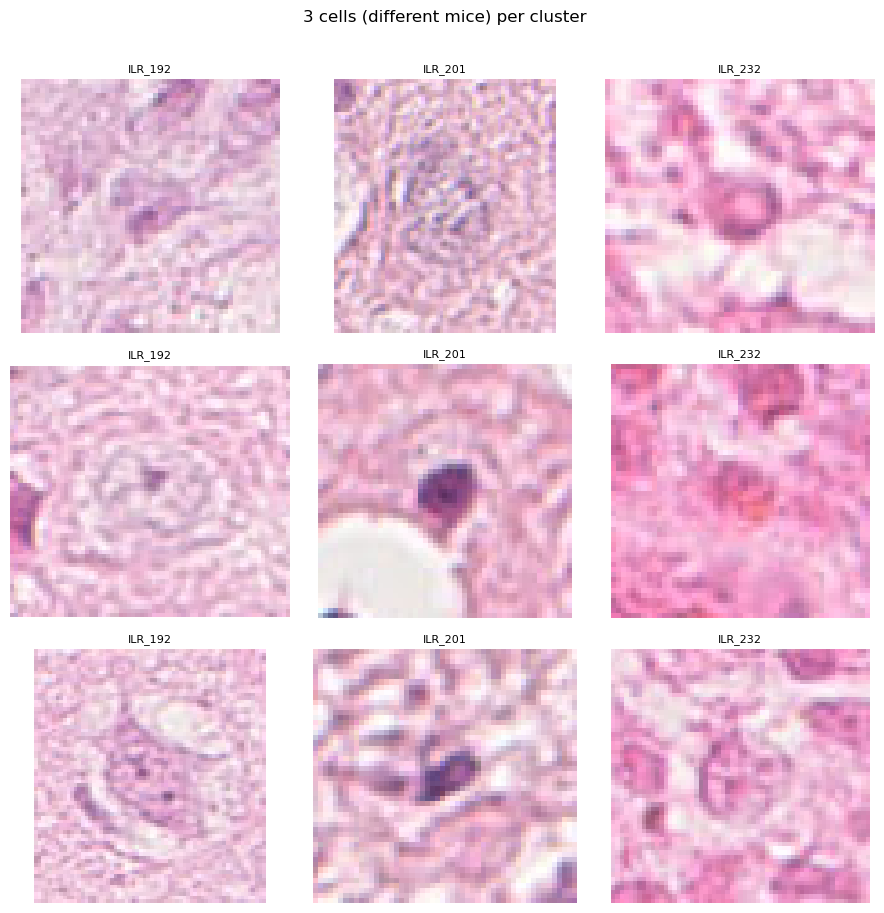

In [23]:
# Plot: rows = clusters, cols = 3 mice
fig, axes = plt.subplots(3, 3, figsize=(9, 3*3))

for cluster in range(3):
    for col, (sample, cell_id) in enumerate(cells_per_cluster[cluster]):
        ax = axes[cluster, col]
        img = extract_cell(sample, cell_id)
        if img:
            ax.imshow(img)
            ax.set_title(f"{sample}", fontsize=8)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f"Cluster {cluster}", fontsize=10)

plt.suptitle("3 cells (different mice) per cluster", y=1.01)
plt.tight_layout()
plt.show()
